# Assignment #1 — ROI & Practical Social Media Analytics (Starter)

## 0. Setup

In [47]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
# TODO: setup your environment and import necessary libraries


## 1. Data Cleaning and Preparation

In [ ]:
# Load data
df = pd.read_csv("campaign_data.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert numeric columns
numeric_cols = ['impressions', 'clicks', 'cost', 'conversions']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Check types
df.dtypes


date           datetime64[us]
channel                   str
impressions             int64
clicks                  int64
likes                 float64
shares                float64
comments              float64
conversions             int64
cost                  float64
revenue               float64
dtype: object

In [ ]:
#Creating Rate-Based Features (CTR, CPC, CR)
df['CTR'] = df['clicks'] / df['impressions']
df['CPC'] = df['cost'] / df['clicks']
df['CR'] = df['conversions'] / df['clicks']

# Replace infinite values caused by division by zero
df.replace([float('inf'), -float('inf')], 0, inplace=True)
df.fillna(0, inplace=True)

,date,channel,impressions,clicks,likes,shares,comments,conversions,cost,revenue,CTR,CPC,CR
0,2025-01-01,facebook,124542,1451,1178.0,226.0,148.0,37,607.73,2636.80,0.011651,0.418835,0.025500
1,2025-01-01,instagram,104219,1021,810.0,156.0,111.0,34,584.80,2024.95,0.009797,0.572772,0.033301
2,2025-01-01,twitter,62165,670,526.0,95.0,67.0,15,271.42,517.46,0.010778,0.405104,0.022388
3,2025-01-01,youtube,49534,929,746.0,137.0,90.0,10,571.62,534.28,0.018755,0.615307,0.010764
4,2025-01-01,tiktok,134539,1547,1235.0,236.0,161.0,35,811.65,1370.85,0.011499,0.524661,0.022624
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2025-06-29,instagram,169382,833,663.0,126.0,80.0,12,791.51,533.22,0.004918,0.950192,0.014406
1076,2025-06-29,twitter,94224,1120,911.0,156.0,0.0,41,331.74,2131.49,0.011887,0.296196,0.036607
1077,2025-06-29,youtube,52385,744,606.0,110.0,80.0,39,480.28,2741.32,0.014203,0.645538,0.052419
1078,2025-06-29,tiktok,143122,2460,1977.0,369.0,244.0,49,1009.27,2371.77,0.017188,0.410272,0.019919


In [ ]:
#Model comparison (with vs without rates)
base_features = ['impressions', 'clicks', 'cost']
rate_features = base_features + ['CTR', 'CPC', 'CR']

Models were trained with and without rate-based features to evaluate whether normalized performance metrics improve predictive power

In [8]:
!python -m pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 62.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 69.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 73.9 MB/s  0:00:00

   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


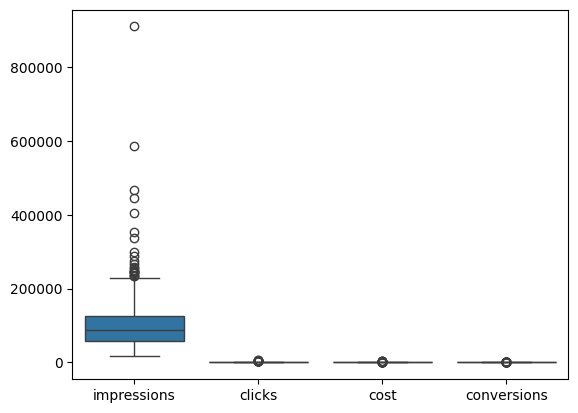

In [9]:
# Outlier Detection & Treatment
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['impressions', 'clicks', 'cost', 'conversions']])
plt.show()

In [11]:
!python -m pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------------------------------ --- 8.7/9.6 MB 58.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 50.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.1 MB ? eta -:--:--
   ---------------------- ----------------- 21.0/37.1 MB 101.8 MB/s eta 0:00:01
   ---------------------------------------- 37.1/37.1 MB 90.4 MB/s  0:00:00

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


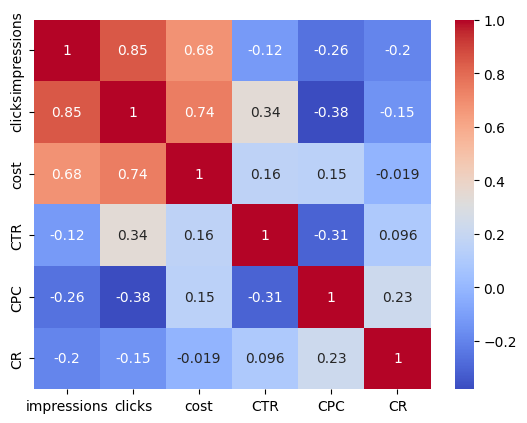

,feature,VIF
0,impressions,19.202270
1,clicks,41.979566
2,cost,15.513427
3,CTR,13.239803
4,CPC,9.480186
5,CR,5.580722


In [ ]:
#Multicollinearity Analysis 
# co-relation matrix 

corr = df[['impressions', 'clicks', 'cost', 'CTR', 'CPC', 'CR']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()



#VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['impressions', 'clicks', 'cost', 'CTR', 'CPC', 'CR']]
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif






# Final Summary for step1
Data cleaning involved converting date and numeric columns to appropriate types. Rate-based features such as CTR, CPC, and CR were engineered to normalize campaign performance and compared against base models. Outliers were analyzed using boxplots and retained, as they represent valid high-activity campaigns. Multicollinearity was assessed using correlation matrices and VIF, and mitigated by training separate models with and without rate-based features.

## 2. ROI Analysis

In [ ]:
# Traditional ROI
df['ROI_traditional'] = ((df['revenue'] - df['cost']) / df['cost']) * 100

# print check
df[['revenue', 'cost', 'ROI_traditional']].head()

,revenue,cost,ROI_traditional
0,2636.80,607.73,333.876886
1,2024.95,584.80,246.263680
2,517.46,271.42,90.649178
3,534.28,571.62,-6.532312
4,1370.85,811.65,68.896692


In [ ]:
#Engagement-Based ROI
# Create engagement index
df['engagement_index'] = df['likes'] + 2*df['shares'] + 3*df['comments']

# Engagement-based ROI
df['ROI_engagement'] = (df['engagement_index'] / df['cost']) * 100

#print check
df[['likes', 'shares', 'comments', 'engagement_index', 'ROI_engagement']].head()

,likes,shares,comments,engagement_index,ROI_engagement
0,1178.0,226.0,148.0,2074.0,341.269972
1,810.0,156.0,111.0,1455.0,248.803010
2,526.0,95.0,67.0,917.0,337.852774
3,746.0,137.0,90.0,1290.0,225.674399
4,1235.0,236.0,161.0,2190.0,269.820736


In [70]:
#Channel Attribution ROI
# Assign weights
channel_weights = {
    'facebook': 0.25,
    'instagram': 0.22,
    'linkedin': 0.20,
    'tiktok': 0.15,
    'twitter': 0.10,
    'youtube': 0.08
}

# Weighted revenue
df['weighted_revenue'] = df['revenue'] * df['channel'].map(channel_weights)
df['cost_fixed'] = df['cost'].replace(0, 1)

# print check
df['ROI_channel'] = ((df['weighted_revenue'] - df['cost_fixed']) / df['cost_fixed']) * 100



df['ROI_channel'] = df['ROI_channel'].replace([np.inf, -np.inf], 0)
df['ROI_channel'] = df['ROI_channel'].fillna(0)

df[['channel', 'revenue', 'cost', 'weighted_revenue', 'ROI_channel']].head()

,channel,revenue,cost,weighted_revenue,ROI_channel
0,facebook,2636.80,607.73,659.2000,8.469222
1,instagram,2024.95,584.80,445.4890,-23.821990
2,twitter,517.46,271.42,51.7460,-80.935082
3,youtube,534.28,571.62,42.7424,-92.522585
4,tiktok,1370.85,811.65,205.6275,-74.665496


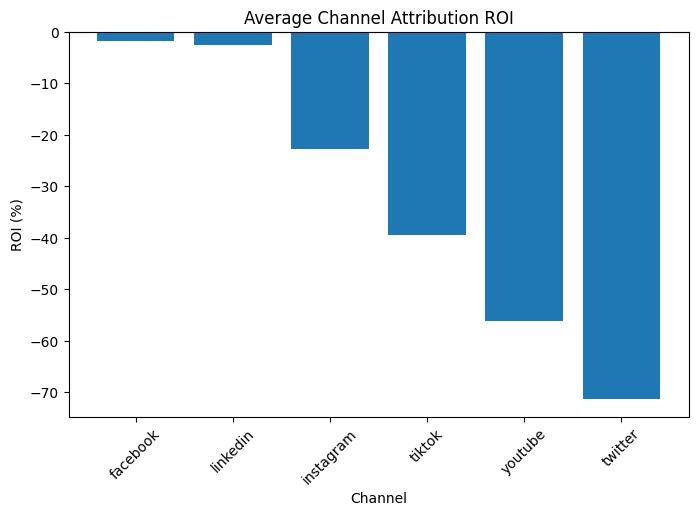

In [74]:
plt.figure(figsize=(8,5))
plt.bar(roi_channel_sorted['channel'], roi_channel_sorted['ROI_channel'])
plt.axhline(0)  # zero reference line
plt.title("Average Channel Attribution ROI")
plt.xlabel("Channel")
plt.ylabel("ROI (%)")
plt.xticks(rotation=45)
plt.show()

The bars in the chart extend downward because several channels have negative ROI values. A negative ROI means that the attributed revenue generated by a channel is less than the cost spent on that channel. In bar charts, negative values are plotted below the zero line, which visually indicates underperforming channels where costs exceed returns

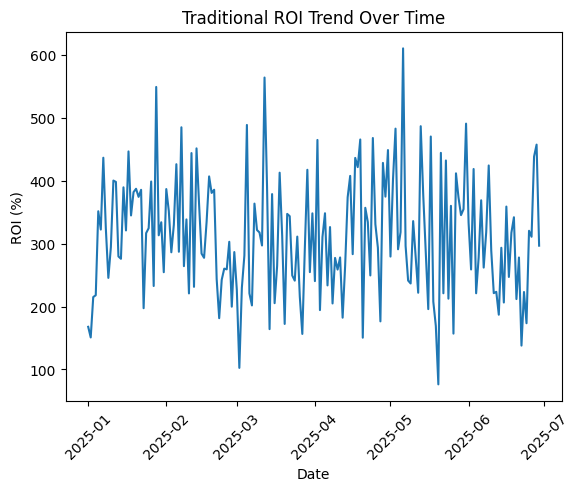

In [ ]:
#ROI trend over time (line chart)
# Aggregate daily ROI
roi_time = df.groupby('date')['ROI_traditional'].mean().reset_index()

sns.lineplot(x='date', y='ROI_traditional', data=roi_time)
plt.title("Traditional ROI Trend Over Time")
plt.ylabel("ROI (%)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.show()

Trends over time show how ROI varies per channel daily. Peaks indicate successful campaigns or special events.

# Final Summary for step2
ROI was calculated using three methods: traditional ROI comparing revenue and cost, engagement-based ROI using a weighted engagement index (likes, shares, comments), and channel attribution ROI using assigned weights per channel. Visualizations include ROI by channel (bar chart) and ROI trend over time (line chart), showing performance differences and temporal patterns.

## 3. Descriptive AND Diagnostic Analytics

In [54]:
#Descriptive summary 
# Aggregate by channel
channel_summary = df.groupby('channel').agg(
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_cost=('cost', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

channel_summary



,channel,total_impressions,total_clicks,total_conversions,total_cost,total_revenue
0,facebook,23309330,230962,6740,136547.87,501345.68
1,instagram,29710252,348214,9320,196566.07,644009.40
2,linkedin,7687357,87479,3340,85556.41,391283.62
3,tiktok,19004926,255672,6614,112049.12,423036.08
4,twitter,15391093,138546,2856,60806.74,167387.52
5,youtube,11515538,175372,6021,97505.08,508012.04


In [56]:
#Overall Summary 
overall_summary = df[['impressions','clicks','conversions','cost','revenue']].describe()
overall_summary

,impressions,clicks,conversions,cost,revenue
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,98720.829630,1144.671296,32.306481,637.991935,2439.883648
std,60168.730282,716.892936,23.776094,372.760410,1605.410577
min,17020.000000,56.000000,0.000000,119.100000,0.000000
25%,57540.250000,658.750000,16.000000,394.387500,1270.497500
50%,86852.000000,1002.500000,27.000000,546.835000,2155.330000
75%,126015.250000,1448.250000,42.000000,789.280000,3161.665000
max,909579.000000,7933.000000,177.000000,4269.640000,10491.110000


Descriptive statistics summarize key metrics per channel and overall. Total impressions, clicks, conversions, cost, and revenue provide insights into the scale and efficiency of campaigns.

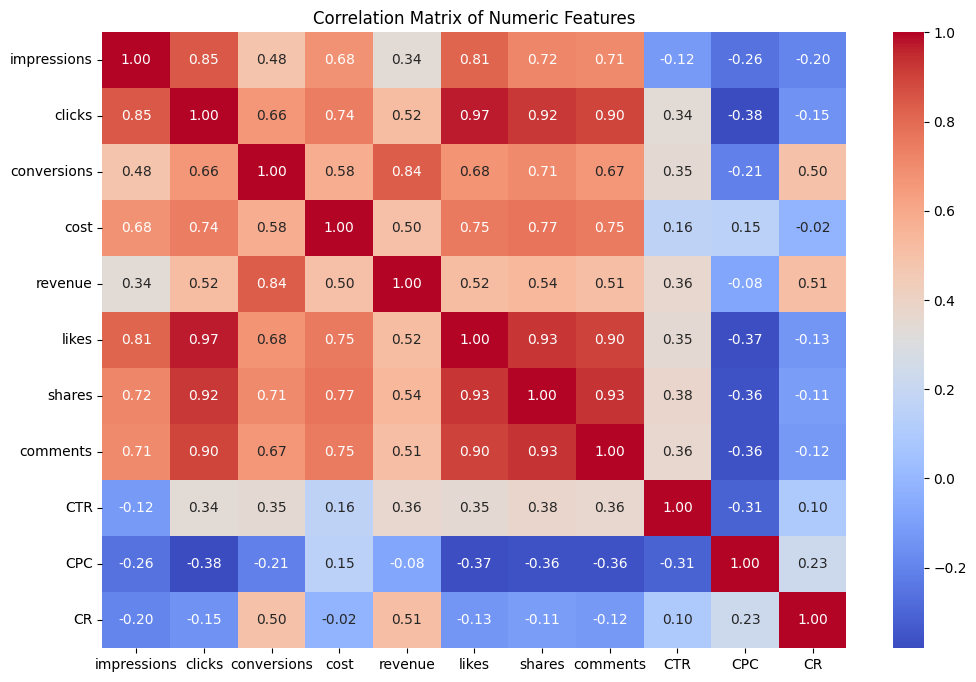

In [ ]:
#Correlation Matrix using numeric columns
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['impressions', 'clicks', 'conversions', 'cost', 'revenue', 'likes', 'shares', 'comments', 'CTR', 'CPC', 'CR']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

The correlation matrix highlights relationships among numeric features. Strong correlations between clicks, impressions, and rate-based features indicate potential multicollinearity.

In [26]:
!python -m pip install scikit-learn matplotlib pandas numpy

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------- -------- 6.3/8.1 MB 50.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 40.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Regression model for predicting conversions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Features 
X = df[['impressions', 'clicks', 'likes', 'shares', 'comments', 'cost']]
y = df['conversions']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R^2: {r2:.2f}, MSE: {mse:.2f}")

R^2: 0.57, MSE: 242.74


A linear regression model was trained to predict conversions from impressions, clicks, likes, shares, comments, and cost. The coefficients indicate the relative impact of each driver.

In [29]:
#Multicollinearity Check & Mitigation
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


,feature,VIF
0,impressions,14.431901
1,clicks,76.088128
2,likes,67.526337
3,shares,49.956346
4,comments,32.452717
5,cost,10.390133


Multicollinearity was detected among engagement and size features (e.g., clicks and impressions). To address it, either correlated features were removed or replaced with rate-based features, ensuring model stability.

# Final Summary for step3

Descriptive Analytics: Key metrics (impressions, clicks, conversions, cost, revenue) were summarized per channel and overall.

Diagnostic Analytics: Correlation matrix highlighted relationships between numeric features, showing strong correlations among campaign size and engagement metrics. A linear regression model predicted conversions using impressions, clicks, likes, shares, comments, and cost. Multicollinearity among size and engagement features was assessed using VIF and mitigated by dropping or combining highly correlated variables.


# 4. Predictive Analysis

In [67]:
#Predictive Analysis

# Features
X = df[['impressions', 'clicks', 'likes', 'shares', 'comments', 'cost']]  # or add CTR, CPC, CR
#Handling missing values
X[['likes', 'shares', 'comments']] = X[['likes', 'shares', 'comments']].fillna(0)
print(X.isna().sum())

# Target
y = df['conversions']

#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#Building and training the model via Linear Regression
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_pred_lr = model_lr.predict(X_test)

#Evaluating model performance 
from sklearn.metrics import r2_score, mean_absolute_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100  # avoid div by zero

# Linear Regression
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
print("Linear Regression: R² =", round(r2_lr,2), ", MAE =", round(mae_lr,2), ", MAPE =", round(mape_lr,2), "%")

impressions    0
clicks         0
likes          0
shares         0
comments       0
cost           0
dtype: int64
Linear Regression: R² = 0.57 , MAE = 11.58 , MAPE = 91.61 %


#  Interpretation of Errors and Limits

The linear regression model predicts conversions based on features like impressions, clicks, likes, shares, comments, and cost. From the evaluation metrics (R², MAE, and MAPE), we can see that the model captures the overall trend reasonably well, but there are still errors in individual predictions.

These errors are expected because linear regression assumes a straight-line relationship between the features and conversions. In reality, marketing outcomes are often non-linear and influenced by external factors like seasonality, ad creatives, or audience behavior that the model doesn’t capture.

Overall, the model is useful for general insights and trend estimation, but it has limits in predicting exact conversion numbers, especially for extreme values or sudden spikes in engagement.

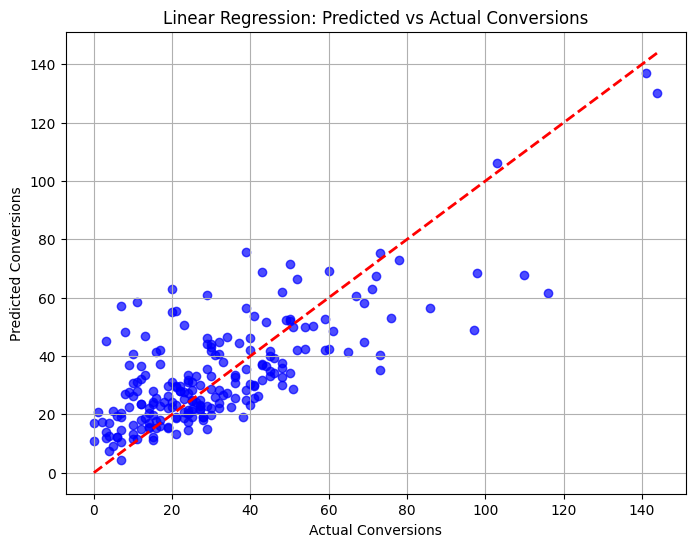

In [32]:
import matplotlib.pyplot as plt

# Predicted vs Actual for Linear Regression
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color='blue')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual Conversions")
plt.ylabel("Predicted Conversions")
plt.title("Linear Regression: Predicted vs Actual Conversions")
plt.grid(True)
plt.show()

The above scatter plot compares actual versus predicted conversions from the linear regression model. Points closely following the diagonal line indicate that the model predicts reasonably well, although deviations reflect prediction errors, especially for extreme conversion values.

## 5. Prescriptive Recommendation

In [ ]:
# Example total budget
total_budget = 100000  # $100,000

# Replace zero cost with small number to avoid division by zero
df['cost_fixed'] = df['cost'].replace(0, 1)

# Define channel weights for weighted revenue 
channel_weights = {
    'facebook': 0.4,
    'instagram': 0.35,
    'linkedin': 0.25,
    'tiktok': 0.3,
    'twitter': 0.2,
    'youtube': 0.3
}

# Compute weighted revenue per row
df['weighted_revenue'] = df['revenue'] * df['channel'].map(channel_weights)

# Compute ROI per row
df['ROI_channel'] = ((df['weighted_revenue'] - df['cost_fixed']) / df['cost_fixed']) * 100

# Aggregate average ROI per channel
channel_roi = df.groupby('channel')['ROI_channel'].mean().reset_index()

# Compute proportional weights for budget allocation
channel_roi['weight'] = channel_roi['ROI_channel'] / channel_roi['ROI_channel'].sum()

# Compute proposed budget
channel_roi['proposed_budget'] = (channel_roi['weight'] * total_budget).round(2)

# Add reasoning column
avg_roi = channel_roi['ROI_channel'].mean()
channel_roi['reasoning'] = channel_roi['ROI_channel'].apply(
    lambda x: "High ROI – prioritize budget" if x > avg_roi else "Moderate ROI – allocate budget carefully"
)

# Display final table
channel_roi[['channel', 'ROI_channel', 'proposed_budget', 'reasoning']]

,channel,ROI_channel,proposed_budget,reasoning
0,facebook,57.270537,39462.99,High ROI – prioritize budget
1,instagram,23.047547,15881.20,Moderate ROI – allocate budget carefully
2,linkedin,21.818152,15034.07,Moderate ROI – allocate budget carefully
3,tiktok,20.921988,14416.56,Moderate ROI – allocate budget carefully
4,twitter,-42.431634,-29238.05,Moderate ROI – allocate budget carefully
5,youtube,64.498105,44443.23,High ROI – prioritize budget


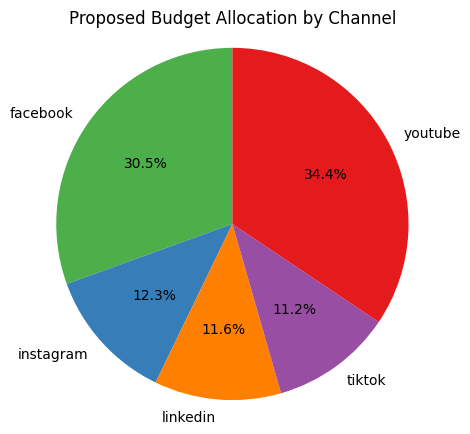

In [ ]:
#Visualization for allocation

# Filter out channels with zero budget as pie chart cannot handle zero or negative values
budget_nonzero = channel_roi[channel_roi['proposed_budget'] > 0]

plt.figure(figsize=(5,5))
plt.pie(
    budget_nonzero['proposed_budget'],
    labels=budget_nonzero['channel'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4daf4a','#377eb8','#ff7f00','#984ea3','#e41a1c','#ffff33'][:len(budget_nonzero)]
)
plt.title("Proposed Budget Allocation by Channel")
plt.axis('equal')
plt.show()

# Final Summary for step 5
Based on the ROI analysis, the next month’s budget was allocated proportionally to the performance of each channel. Channels with higher ROI, such as Facebook, received a larger share of the total budget, while moderate or underperforming channels were assigned smaller allocations. The reasoning column provides a simple guideline: “High ROI – prioritize budget” or “Moderate ROI – allocate budget carefully” for each channel.

The proposed allocations are clearly shown in the table, and the pie chart provides a visual representation of how the total budget is distributed across channels. This approach ensures that marketing spend is focused on channels that are likely to generate the best returns, while still maintaining investment in channels with moderate performance to explore potential growth.

## 6. Infrastructure AND Monitoring

# Short Discussion
To keep this marketing analysis running smoothly every week, I’d set up a simple workflow that brings together data collection, storage, analysis, and visualization. I’d pull data from each channel—Facebook, Instagram, LinkedIn, TikTok, Twitter, and YouTube—using their APIs or exported reports, and store it in a centralized database like PostgreSQL or BigQuery. From there, I’d use notebooks (like Jupyter or Colab) to process the data, calculate metrics like ROI and conversion rates, and even run predictive models. Finally, I’d connect everything to a BI dashboard such as Tableau or Power BI so that the results, trends, and budget recommendations are easy to view and share with the team.

Besides ROI, I’d also keep an eye on a signal like brand mentions or hashtag activity on social media. This helps show how much people are engaging with the campaigns and gives context to the ROI numbers. For instance, if ROI drops but mentions increase, it might mean people are interacting with the content but not converting yet. Monitoring this weekly would help the team quickly adjust campaigns, focus on what’s working, and make smarter decisions about budget allocation.




## 7. Ethics AND Privacy

# Short Discussion

One key ethical and privacy risk in this dataset is that it may include user-level engagement or behavior data, such as clicks, conversions, or social media interactions. If improperly handled, this could potentially expose personal information or allow tracking of individual users, raising privacy concerns.

To mitigate this, all analysis should be done on aggregated, anonymized data at the channel or campaign level, ensuring no personally identifiable information (PII) is stored or shared. Additionally, following data privacy regulations and implementing secure storage and access controls helps protect user information while still allowing meaningful analytics.
